In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans

In [3]:
# Global variables
separator = "_"*20
divider = f"\n{"*" * 90}\n"

data = {
    "Age": [22, 34, 45, np.nan, 52, 23, 40, 60, 18, 31],
    "Yearly_Spend": [15, np.nan, 82, 10, 91, 25, 75, np.nan, 12, 55],
    "Purchased": [0, 1, 1, 0, 1, 0, 1, 1, 0, 1] # 0: No, 1: Yes
}

df = pd.DataFrame(data)

df = pd.DataFrame(data)
print(f"{separator} DataFrame: {separator}\n{df}")

____________________ DataFrame: ____________________
    Age  Yearly_Spend  Purchased
0  22.0          15.0          0
1  34.0           NaN          1
2  45.0          82.0          1
3   NaN          10.0          0
4  52.0          91.0          1
5  23.0          25.0          0
6  40.0          75.0          1
7  60.0           NaN          1
8  18.0          12.0          0
9  31.0          55.0          1


In [4]:
print(f"{separator} Missing Data Info: {separator}\n{df.isnull().sum()}")
print(f"{divider}\n{separator} Dataset Statistcal Summary: {separator}\n{df.describe()}")
print(f"{divider}\n{separator} Dataset Shape: {separator}{df.shape}")
print(f"{divider}\n{separator} DataFrame Summary: {separator}")
print(df.info())

____________________ Missing Data Info: ____________________
Age             1
Yearly_Spend    2
Purchased       0
dtype: int64

******************************************************************************************

____________________ Dataset Statistcal Summary: ____________________
             Age  Yearly_Spend  Purchased
count   9.000000       8.00000  10.000000
mean   36.111111      45.62500   0.600000
std    14.347861      34.00814   0.516398
min    18.000000      10.00000   0.000000
25%    23.000000      14.25000   0.000000
50%    34.000000      40.00000   1.000000
75%    45.000000      76.75000   1.000000
max    60.000000      91.00000   1.000000

******************************************************************************************

____________________ Dataset Shape: ____________________(10, 3)

******************************************************************************************

____________________ DataFrame Summary: ____________________
<class 'pandas.core.

In [5]:
# Treating missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Yearly_Spend"] = df["Yearly_Spend"].fillna(df["Yearly_Spend"].mean())

print(f"{separator} DataFrame after Treating missing values: {separator}\n{df}")
print(f"{divider}\n{separator} Missing Data Info: {separator}\n{df.isnull().sum()}")

____________________ DataFrame after Treating missing values: ____________________
         Age  Yearly_Spend  Purchased
0  22.000000        15.000          0
1  34.000000        45.625          1
2  45.000000        82.000          1
3  36.111111        10.000          0
4  52.000000        91.000          1
5  23.000000        25.000          0
6  40.000000        75.000          1
7  60.000000        45.625          1
8  18.000000        12.000          0
9  31.000000        55.000          1

******************************************************************************************

____________________ Missing Data Info: ____________________
Age             0
Yearly_Spend    0
Purchased       0
dtype: int64


In [6]:
# Features and Target
X = df[["Age", "Yearly_Spend"]]
y = df["Purchased"]

In [7]:
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

In [8]:
# Svc model initialization
svc_model = SVC(kernel="linear", random_state=0)
svc_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
# Making predition - y_pred
y_pred = svc_model.predict(X_test)

# Evaluate using accuracy_score, confusion_matrix and classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\n=> The accuracy: {accuracy}")
print(f"{divider}\n=> The Confusion Matrix:\n{conf_mat}")
print(f"{divider}\n=> The Classification Report:\n{report}")


=> The accuracy: 1.0

******************************************************************************************

=> The Confusion Matrix:
[[1 0]
 [0 4]]

******************************************************************************************

=> The Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



Decision function range: -1.662748192337717 2.217374118194285


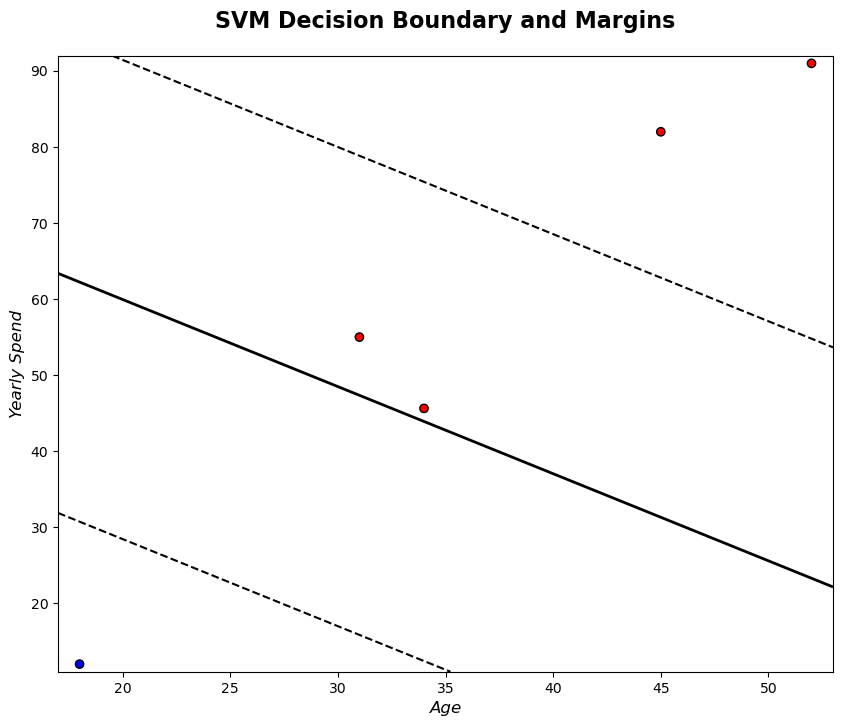

In [10]:
# Visualize the decision boundary
# Plotting Scatter and Plot
plt.figure(figsize=(10, 8))

X_test = X_test.values # Convert to numpy array for plotting

# Scatter plot of test points colored by class
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test , cmap="bwr", edgecolors='k')

# Define grid boundaries based on test data
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

xx , yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Compute the decision function on the grid
# Z = svc_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=X_train.columns)

Z = svc_model.decision_function(grid_df).reshape(xx.shape)
print("Decision function range:", Z.min(), Z.max())

# Plot decision boundary and margins
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2) # Hyperplane
plt.contour(xx, yy, Z, levels=[-1, 1], colors='k', linestyles="--") # Margins (hard and soft margins)

plt.title("SVM Decision Boundary and Margins", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Age", fontsize=12, fontstyle="italic")
plt.ylabel("Yearly Spend", fontsize=12, fontstyle="italic")
plt.show()

In [11]:
# decision_tree model initialization
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
# Making predition - y_pred
y_pred = svc_model.predict(X_test)

# Evaluate using accuracy_score, confusion_matrix and classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\n=> The accuracy: {accuracy}")
print(f"{divider}\n=> The Confusion Matrix:\n{conf_mat}")
print(f"{divider}\n=> The Classification Report:\n{report}")


=> The accuracy: 1.0

******************************************************************************************

=> The Confusion Matrix:
[[1 0]
 [0 4]]

******************************************************************************************

=> The Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



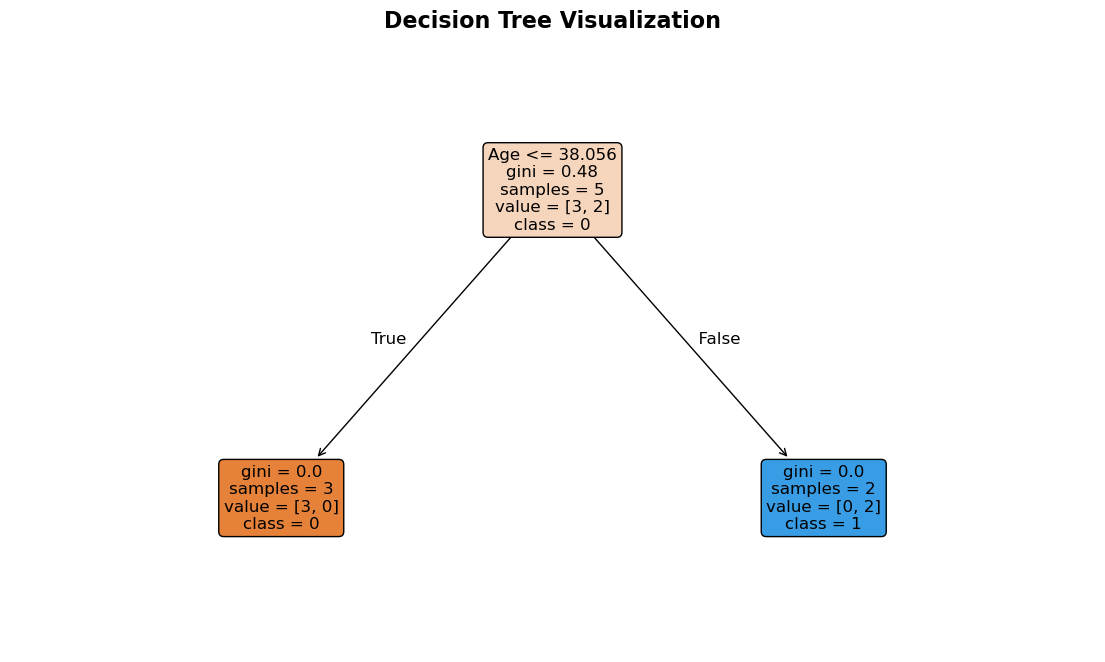

In [13]:
# Plotting Decision Tree
plt.figure(figsize=(14, 8))

plot_tree(
    dt_model, 
    feature_names=["Age", "Yearly_Spend"], 
    class_names=["0", "1"], 
    filled=True, 
    rounded=True, 
    fontsize=12
)

plt.title("Decision Tree Visualization", fontsize=16, fontweight="bold")
plt.show()

In [14]:
# Step 3: Initialize the K-Means Model
kmeans = KMeans(n_clusters=2, random_state=0)

# Step 4: Fit the Model to the Data
kmeans.fit(df)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [15]:
# Step 5: Obtain Cluster Centroids and Labels
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
print("=> Centroids:\n", centroids)
print(f"{divider}\n=> Labels:", labels)

=> Centroids:
 [[26.62222222 21.525       0.2       ]
 [45.6        69.725       1.        ]]

******************************************************************************************

=> Labels: [0 0 1 0 1 0 1 1 0 1]


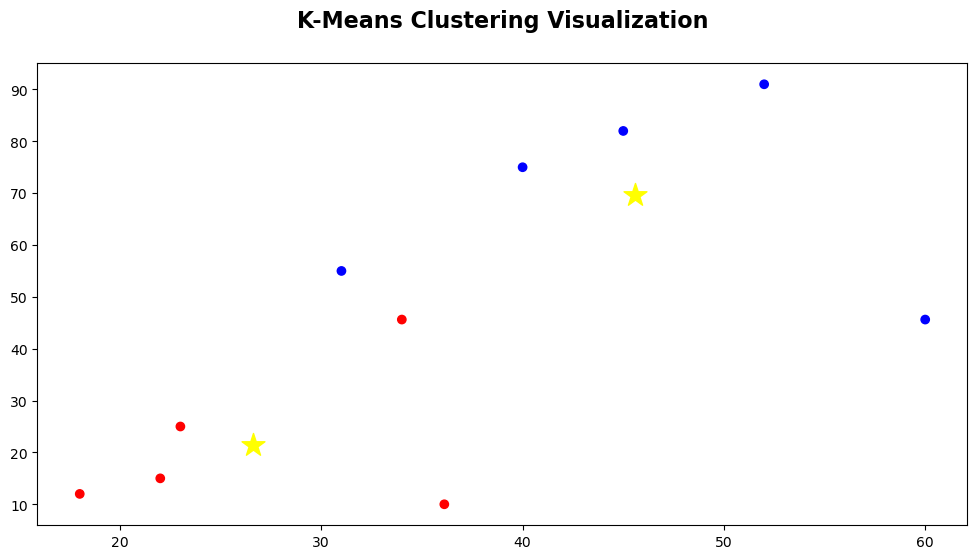

In [16]:
# Step 6: Visualize Clusters and Centroids
df = df.values

colors = ["red" if label == 0 else "blue" for label in labels]

plt.figure(figsize=(12, 6))

plt.scatter(df[:, 0], df[:, 1], c=colors)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c="yellow", marker='*')
plt.title("K-Means Clustering Visualization", fontsize=16, fontweight="bold", pad=26)
plt.show()